#Tarea - Agente con ambiente Taxi

In [3]:
!pip install swig
!pip install "gymnasium[box2d]"

In [5]:
import gymnasium as gym
import numpy as np
from random import randint

# Inicialización del ambiente Taxi-v3
# Este ambiente tiene 500 estados y 6 acciones posibles
env = gym.make("Taxi-v3")

# Tabla Q corregida: 500 estados x 6 acciones
q_table = np.zeros([500, 6])

# Parámetros del algoritmo
alfa = 0.1
gamma = 0.99
epsilon = 1.0
decay = 0.999
episodios = 1000 # Aumentado para mejor aprendizaje en Taxi
lista_recompenzas = []

for episodio in range(episodios):
    # En Taxi-v3, obs es un entero del 0 al 499
    estado, info = env.reset()
    final = False
    recompensa_total = 0

    while not final:
        # Política Epsilon-Greedy
        if np.random.random() > epsilon:
            accion = np.argmax(q_table[estado])
        else:
            accion = env.action_space.sample()

        # Ejecutar acción
        nuevo_estado, recompensa, term, trunc, info = env.step(accion)

        # Actualización de la tabla Q (Ecuación de Bellman)
        q_table[estado][accion] += alfa * (recompensa + gamma * np.max(q_table[nuevo_estado]) - q_table[estado][accion])

        estado = nuevo_estado
        recompensa_total += recompensa
        final = term or trunc

    # Decaimiento de epsilon
    epsilon = max(0.01, epsilon * decay)
    lista_recompenzas.append(recompensa_total)

    if (episodio + 1) % 100 == 0:
        print(f"Episodio: {episodio+1} | Recompensa promedio (últimos 100): {np.mean(lista_recompenzas[-100:]):.2f} | Epsilon: {epsilon:.2f}")

env.close()

Episodio: 100 | Recompensa promedio (últimos 100): -738.89 | Epsilon: 0.90
Episodio: 200 | Recompensa promedio (últimos 100): -669.14 | Epsilon: 0.82
Episodio: 300 | Recompensa promedio (últimos 100): -586.11 | Epsilon: 0.74
Episodio: 400 | Recompensa promedio (últimos 100): -445.50 | Epsilon: 0.67
Episodio: 500 | Recompensa promedio (últimos 100): -349.05 | Epsilon: 0.61
Episodio: 600 | Recompensa promedio (últimos 100): -261.66 | Epsilon: 0.55
Episodio: 700 | Recompensa promedio (últimos 100): -203.33 | Epsilon: 0.50
Episodio: 800 | Recompensa promedio (últimos 100): -128.63 | Epsilon: 0.45
Episodio: 900 | Recompensa promedio (últimos 100): -89.62 | Epsilon: 0.41
Episodio: 1000 | Recompensa promedio (últimos 100): -64.09 | Epsilon: 0.37


Prueba finalizada. Recompensa total: -200


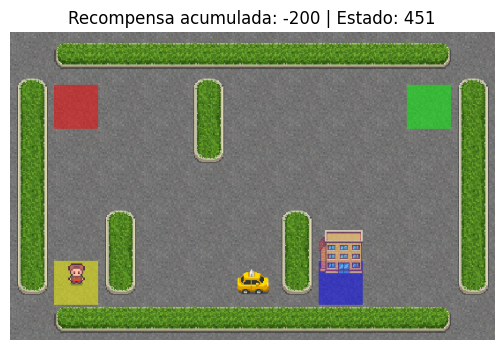

In [6]:
import matplotlib.pyplot as plt
from IPython import display
import numpy as np

# Crear el ambiente para visualización
# Usamos render_mode="rgb_array" para poder mostrarlo en el notebook
env_render = gym.make("Taxi-v3", render_mode="rgb_array")

estado_render, info_render = env_render.reset()
final_render = False
recompensa_total_render = 0

# Preparar la visualización
plt.figure(figsize=(10, 4))
img_display = plt.imshow(env_render.render())
plt.axis('off')

while not final_render:
    # Seleccionar la mejor acción según la tabla Q entrenada anteriormente
    # Como el estado es un entero, lo usamos directamente como índice
    accion_render = np.argmax(q_table[estado_render])

    # Ejecutar acción
    nuevo_estado_render, recompensa_render, terminated_render, truncated_render, info_render = env_render.step(accion_render)

    recompensa_total_render += recompensa_render
    estado_render = nuevo_estado_render
    final_render = terminated_render or truncated_render

    # Actualizar el frame visual
    img_display.set_data(env_render.render())
    plt.title(f"Recompensa acumulada: {recompensa_total_render} | Estado: {estado_render}")
    display.display(plt.gcf())
    display.clear_output(wait=True)

print(f"Prueba finalizada. Recompensa total: {recompensa_total_render}")
env_render.close()

In [7]:
#Esta visualización con el render_mode="human" solo logré verla en VScode, en Colab no se muestra
env= gym.make("Taxi-v3", render_mode="human")

estado, info = env.reset()  # En CliffWalking, el estado ya es un entero
final = False
recompensa_total = 0

while not final:
    # Seleccionar la mejor acción según la tabla Q entrenada
    accion = np.argmax(q_table[estado])

    # Usar la acción directamente como entero para el ambiente discreto
    nuevo_estado, recompensa, terminated, truncated, info = env.step(int(accion))
    estado = nuevo_estado  # Ya es un entero, no necesita discretización

    recompensa_total += recompensa
    final = terminated or truncated

print(f"Recompensa de la prueba: {recompensa_total}")
env.close()

Recompensa de la prueba: -200
